# CS156: Pipeline - Second Draft

**Can You Diagnose Autism From Brain Noise?**

There’s a persistent idea in computational neuroscience that you can look at a brain scan and read *something* meaningful: a diagnosis, a trait, or a difference in how someone thinks. It’s a compelling idea. It’s also, at best, an approximation.

This project starts from a deliberately uncomfortable question:

> If you take a noisy, indirect measurement of brain activity and reduce it to correlations between ~200 regions, is there actually enough signal left to distinguish individuals with Autism Spectrum Disorder (ASD) from controls?

The data used here are resting-state fMRI time series, summarized as functional connectivity matrices. In practice, this means:
- we are not observing neural activity directly  
- we are not measuring interactions between regions  
- we are measuring statistical co-variation under a long chain of preprocessing assumptions  

So the object we feed into our models is already several steps removed from anything we might confidently call “brain function.”

Given that, the goal of this project is not to build a diagnostic tool, but rather to test how different modeling assumptions behave when applied to this representation.

Each subject is represented as a connectivity matrix derived from ROI time series (`rois_cc200`). From there, we ask a simple but pointed question:

> Does treating the brain as a graph actually help, or are we just adding structure to noise?

To answer this, we compare four approaches:

* Logistic Regression on flattened connectivity features  
* A multilayer perceptron (MLP) on the same representation  
* A graph convolutional network (GCN) that assumes connectivity structure matters  
* A graph attention network (GAT) that learns which connections to emphasize  

All models operate on the same underlying data, allowing differences in performance to reflect model assumptions rather than differences in input.

If graph-based models outperform simpler baselines, that suggests there is meaningful relational structure in the data. If they do not, it raises a more uncomfortable possibility: that increasing model sophistication does not recover signal that may not be there to begin with.

The notebook proceeds as follows:

1. Load and verify the curated dataset  
2. Construct functional connectivity matrices  
3. Prepare inputs for each modeling approach  
4. Train and evaluate models under consistent conditions  
5. Compare results and analyze differences  

The aim is not to settle whether functional connectivity can diagnose ASD, but to probe how far this representation can be pushed—and where it breaks down.

# Data

The dataset is derived from the ABIDE preprocessed repository (FCP-INDI), using derivatives generated by the CPAC pipeline with the `filt_global` preprocessing strategy and the CC200 functional parcellation. Each subject is represented by ROI-level time series extracted from resting-state fMRI data.

Subjects are included based on:
- Valid phenotypic entry (`FILE_ID != "no_filename"`)
- Diagnostic label restricted to ASD and control groups (`DX_GROUP ∈ {1, 2}`)
- Availability of corresponding CC200 time series files

Subjects with missing files, invalid dimensions, or failed loading are excluded. The final dataset contains 1035 subjects, split into training (828) and test (207) sets using stratified sampling over diagnosis labels.


## Preprocessing and CC200 representation

All imaging data are derived from the ABIDE Preprocessed derivatives hosted on the FCP-INDI Amazon S3 bucket. We specifically use:

- Pipeline: C-PAC (`cpac`)
- Strategy: global signal regression with band-pass filtering (`filt_global`)
- Derivative: CC200 ROI time series (`rois_cc200`)

Each subject is identified by a unique `FILE_ID`, which is used to retrieve precomputed ROI time series stored as `.1D` files.

The input to our models consists of precomputed ROI time series extracted using the Craddock 200 (CC200) functional parcellation. Each subject’s data is represented as a matrix:

$$
[
X \in \mathbb{R}^{T \times 200}
]
$$

where rows correspond to time points and columns correspond to ROIs.

Time series orientation is standardized such that inputs are reshaped to \(T \times 200\) if required. No additional temporal preprocessing (e.g., trimming of initial volumes or additional filtering) is applied beyond the ABIDE-provided derivatives.

No additional per-ROI normalization or z-scoring is performed prior to connectivity estimation.


# Feature Construction

Functional connectivity (FC) is computed independently for each subject using Pearson correlation between ROI time series:

$$
[
\text{FC}_{ij} = \mathrm{corr}(X_i, X_j)
]
$$ 

To stabilize variance and improve statistical properties, FC matrices are transformed using the Fisher z-transform:

$$
[
Z = \operatorname{arctanh}(R)
]
$$

Prior to transformation, correlation values are clipped to $(-1 + \epsilon, 1 - \epsilon)$ to ensure numerical stability. After transformation:
- NaN and infinite values are replaced with zero
- Diagonal entries are set to zero

The resulting Fisher z-transformed FC matrix serves as the shared representation for all downstream models.


## Matrix Representation

Each FC matrix is vectorized by extracting the upper triangular portion (excluding the diagonal), yielding a feature vector of size:

$$
[
\frac{200 \cdot 199}{2} = 19{,}900
]
$$

These features are standardized using z-score normalization (fit on training data only).

This representation is used for classical machine learning models (Logistic Regression and MLP).

## Graph Representation

Each subject is represented as a graph constructed from its FC matrix.

### Graph construction
- Nodes correspond to ROIs (200 total)
- For each node, edges are formed to the top \(k = 10\) ROIs with highest absolute FC magnitude
- Edge selection is based on connectivity strength \(|Z_{ij}|\)
- The graph is symmetrized to form an undirected structure
- Self-loops are excluded

This produces a sparse k-nearest-neighbor graph over functional connectivity structure.

### Edge definition
Edges encode connectivity structure only and are treated as unweighted. Correlation values are not used as edge weights during message passing.


### Node features

Each node is represented by its corresponding FC connectivity profile:

$$
[
x_i = Z_{i,:}
]
$$

i.e., the $(i)$-th row of the Fisher z-transformed FC matrix.

Node features are normalized per node using z-score normalization:

$$
[
x_i \leftarrow \frac{x_i - \mu_i}{\sigma_i}
]
$$

where $(\mu_i)$ and $(\sigma_i)$ are the mean and standard deviation of the $(i)$-th node’s feature vector.

## Key methodological notes

- Fisher z-transform is applied consistently across all representations
- Graph topology is determined by connectivity magnitude, not sign
- GNN models operate on unweighted graphs, with structure derived from FC
- Both ML and GNN models are based on the same underlying FC representation
- No dimensionality reduction (e.g., PCA) is applied
- No additional temporal preprocessing is performed beyond ABIDE derivatives

In [3]:
# Load time-series data and compute Fisher z-transformed functional connectivity matrices
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

base_dir = Path("data") / "abide_fmri"
ts_dir = base_dir / "timeseries"
fc_dir = base_dir / "connectivity_matrices"

print("[INIT] Ensuring output directory exists...")
fc_dir.mkdir(parents=True, exist_ok=True)

subjects_path = base_dir / "subjects_clean.csv"

def fisher_z_transform(corr: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    """Apply Fisher z-transform safely to correlation matrix."""
    clipped = np.clip(corr, -1 + eps, 1 - eps)
    return np.arctanh(clipped)

# Step 1: Load subject list from CSV or filesystem
print("[STEP 1] Getting subject list...")

if subjects_path.exists():
    print("  -> Reading CSV")
    subjects_df = pd.read_csv(subjects_path)
    print("  -> CSV loaded")

    file_ids = subjects_df["FILE_ID"].dropna().astype(str).drop_duplicates().tolist()
    print("  -> Extracted FILE_IDs")
else:
    print("  -> No CSV found, scanning timeseries folder")
    file_ids = sorted(p.stem for p in ts_dir.glob("*.1D"))

print(f"[STEP 1 DONE] {len(file_ids)} subjects")

valid_ids = []
failed_ids = []
skipped_ids = []
roi_count = None

# Step 2: Process each subject's time series and compute functional connectivity
print("[STEP 2] Starting processing loop...")

for i, fid in enumerate(tqdm(file_ids, desc="Processing")):
    ts_path = ts_dir / f"{fid}.1D"
    fc_path = fc_dir / f"{fid}.npy"

    # Skip subjects whose connectivity matrices already exist
    if fc_path.exists():
        skipped_ids.append(fid)
        valid_ids.append(fid)
        continue

    if not ts_path.exists():
        print(f"[WARN] Missing file: {fid}")
        failed_ids.append(fid)
        continue

    try:
        ts = np.loadtxt(ts_path)

        if ts.ndim != 2:
            print(f"[WARN] Bad shape (ndim) for {fid}: {ts.ndim}")
            failed_ids.append(fid)
            continue

        # Ensure time series is (time_points, 200_ROIs) format
        if ts.shape[1] == 200:
            pass
        elif ts.shape[0] == 200:
            ts = ts.T
            print(f"[INFO] Transposed: {fid}")
        else:
            print(f"[WARN] Unexpected shape for {fid}: {ts.shape}")
            failed_ids.append(fid)
            continue

        # Compute Pearson correlation between ROI time series
        corr = np.corrcoef(ts, rowvar=False)

        # Apply Fisher z-transform immediately after correlation computation
        z = fisher_z_transform(corr)
        z = np.nan_to_num(z).astype(np.float32)  # Replace NaN/inf with 0 and convert to float32
        np.fill_diagonal(z, 0)  # Remove self-loops

        if roi_count is None:
            roi_count = z.shape[0]
            print(f"[INFO] ROI count set to {roi_count}")

        if z.shape != (roi_count, roi_count):
            print(f"[WARN] Shape mismatch for {fid}: {z.shape}")
            failed_ids.append(fid)
            continue

        np.save(fc_path, z)
        valid_ids.append(fid)

    except Exception as e:
        print(f"[ERROR] Failed {fid}: {e}")
        failed_ids.append(fid)

print("[STEP 2 DONE] Processing finished")

# Step 3: Create index file linking FILE_IDs to their connectivity matrices and labels
print("[STEP 3] Building index...")

index_df = pd.DataFrame({"FILE_ID": valid_ids})

if subjects_path.exists():
    subjects_clean = subjects_df[subjects_df["FILE_ID"].isin(valid_ids)].copy()
    subjects_clean.to_csv(base_dir / "subjects_with_fc.csv", index=False)

    index_df = index_df.merge(
        subjects_clean[["FILE_ID", "DX_GROUP"]],
        on="FILE_ID",
        how="left"
    )

index_df.to_csv(base_dir / "connectivity_index.csv", index=False)

# Summary of processing results
print("\n--- Summary ---")
print(f"Processed new: {len(valid_ids) - len(skipped_ids)}")
print(f"Skipped: {len(skipped_ids)}")
print(f"Failed: {len(failed_ids)}")

if roi_count is not None:
    print(f"Matrix shape: ({roi_count}, {roi_count})")

if failed_ids:
    print("Example failures:", failed_ids[:10])

[INIT] Ensuring output directory exists...
[STEP 1] Getting subject list...
  -> Reading CSV
  -> CSV loaded
  -> Extracted FILE_IDs
[STEP 1 DONE] 1035 subjects
[STEP 2] Starting processing loop...


Processing: 100%|██████████| 1035/1035 [00:00<00:00, 11033.07it/s]

[STEP 2 DONE] Processing finished
[STEP 3] Building index...

--- Summary ---
Processed new: 0
Skipped: 1035
Failed: 0


In [4]:
# Convert Fisher z-transformed connectivity matrices to sparse PyG graph objects with unweighted top-k edge selection
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from tqdm import tqdm
from torch_geometric.data import Data

base_dir = Path("data") / "abide_fmri"
fc_dir = base_dir / "connectivity_matrices"
index_path = base_dir / "connectivity_index.csv"
pyg_dir = base_dir / "pyg"
pyg_dir.mkdir(parents=True, exist_ok=True)

TOP_K = 10

def matrix_to_topk_edge_index(adj: np.ndarray, k: int = 10):
    """Extract unweighted top-k edges per node from adjacency matrix.
    Keeps symmetric edges (undirected graph); self-loops removed.
    Returns edge_index (2 x num_edges).
    """
    n = adj.shape[0]
    a = adj.copy().astype(np.float32)
    np.fill_diagonal(a, 0.0)

    edges = set()
    for i in range(n):
        row = a[i]

        # Select top-k neighbors by absolute connectivity magnitude for this node
        valid_idx = np.where(np.abs(row) > 0)[0]
        if len(valid_idx) >= k:
            idx = valid_idx[np.argsort(np.abs(row[valid_idx]))[-k:]]
        else:
            idx = valid_idx

        for j in idx:
            if i == j:
                continue
            u, v = sorted((i, j))
            edges.add((u, v))

    if not edges:
        return torch.empty((2, 0), dtype=torch.long)

    edge_list = []

    # Add bidirectional edges for undirected graph representation
    for (u, v) in edges:
        edge_list.append([u, v])
        edge_list.append([v, u])

    edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
    return edge_index

# Load subject index and build graph objects
index_df = pd.read_csv(index_path)
label_map = {1: 1, 2: 0}  # DX_GROUP: 1=ASD -> 1, 2=Control -> 0

graphs = []
skipped = []

for _, row in tqdm(index_df.iterrows(), total=len(index_df), desc="Building graphs"):
    fid = str(row["FILE_ID"])
    y_raw = row.get("DX_GROUP", np.nan)

    mat_path = fc_dir / f"{fid}.npy"
    if not mat_path.exists():
        skipped.append(fid)
        continue

    # Matrices are already Fisher z-transformed in the FC construction cell.
    adj = np.load(mat_path)

    if adj.ndim != 2 or adj.shape[0] != adj.shape[1]:
        skipped.append(fid)
        continue

    adj = np.nan_to_num(adj).astype(np.float32)
    np.fill_diagonal(adj, 0.0)

    # Unweighted sparse structure via top-k selection.
    edge_index = matrix_to_topk_edge_index(adj, k=TOP_K)
    assert edge_index.max() < adj.shape[0]

    # Node features: full connectivity profile (200-dim vector per ROI, normalized)
    x = torch.tensor(adj, dtype=torch.float32)
    x = (x - x.mean(dim=1, keepdim=True)) / (x.std(dim=1, keepdim=True) + 1e-6)
    assert x.shape == (adj.shape[0], adj.shape[1])

    data = Data(
        x=x,
        edge_index=edge_index,
        y=None,
        file_id=fid
    )

    if pd.notna(y_raw):
        data.y = torch.tensor([label_map[int(y_raw)]], dtype=torch.long)

    graphs.append(data)

# Save graph list to disk
out_path = pyg_dir / f"graphs_top{TOP_K}.pt"
torch.save(graphs, out_path)

print(f"Saved {len(graphs)} graphs -> {out_path}")
print(f"Skipped: {len(skipped)}")

if graphs:
    g = graphs[0]
    print(f"Graph sanity: nodes={g.num_nodes}, edges={g.edge_index.shape[1]}, unweighted graph used")

Building graphs: 100%|██████████| 1035/1035 [00:05<00:00, 203.67it/s]


Saved 1035 graphs -> data/abide_fmri/pyg/graphs_top10.pt
Skipped: 0
Graph sanity: nodes=200, edges=2660, unweighted graph used


# Splitting the Data

The dataset is split into training and test sets using stratified sampling based on diagnosis labels (DX_GROUP), preserving class balance.

The final split consists of:
- Training set: 828 subjects (ASD: 404, Control: 424)
- Test set: 207 subjects (ASD: 101, Control: 106)

Class imbalance is mild in both splits, with ASD/control proportions remaining close to balanced. 

However, it should be noted that subjects from all acquisition sites are represented in both splits, resulting in similar site distributions across training and test data. This setup evaluates generalization to new subjects under matched multi-site conditions, rather than generalization to entirely unseen sites.

In [5]:
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split
import torch

base = Path("data/abide_fmri")
mat_dir = base / "connectivity_matrices"
graph_path = base / "pyg" / "graphs_top10.pt"
index_path = base / "connectivity_index.csv"

# Step 1: Load subject labels
idx = pd.read_csv(index_path)[["FILE_ID", "DX_GROUP"]].drop_duplicates().copy()

# Step 2: Keep only subjects that actually have matrix files (enforce consistency)
matrix_ids = {p.stem for p in mat_dir.glob("*.npy")}
idx = idx[idx["FILE_ID"].isin(matrix_ids)].reset_index(drop=True)

# Step 3: Stratified 80/20 split preserving class balance at subject level
train_ids, test_ids = train_test_split(
    idx["FILE_ID"],
    test_size=0.2,
    random_state=42,
    stratify=idx["DX_GROUP"]
)
train_ids = set(train_ids)
test_ids = set(test_ids)

split_df = idx.copy()
split_df["split"] = split_df["FILE_ID"].map(lambda s: "train" if s in train_ids else "test")

# Step 4: Save split manifest as single source of truth
split_df.to_csv(base / "subject_split.csv", index=False)
split_df[split_df["split"] == "train"].to_csv(base / "train_subjects.csv", index=False)
split_df[split_df["split"] == "test"].to_csv(base / "test_subjects.csv", index=False)

print("Total:", len(split_df))
print(split_df["split"].value_counts())
print("\nClass counts by split:")
print(pd.crosstab(split_df["split"], split_df["DX_GROUP"]))

# Step 5: Split graphs using graph metadata IDs to ensure consistency between representations
if not graph_path.exists():
    raise FileNotFoundError(
        f"Missing {graph_path}. Re-run the graph-construction cell first to recreate graphs_top10.pt."
    )

# PyTorch >=2.6 defaults to weights_only=True, which cannot unpickle PyG Data objects.
graphs = torch.load(graph_path, weights_only=False)
graph_by_id = {}
missing_id_count = 0

for g in graphs:
    gid = getattr(g, "file_id", None)
    if gid is None:
        gid = getattr(g, "fid", None)
    if gid is None:
        missing_id_count += 1
        continue
    graph_by_id[str(gid)] = g

train_graphs = [graph_by_id[fid] for fid in sorted(train_ids) if fid in graph_by_id]
test_graphs = [graph_by_id[fid] for fid in sorted(test_ids) if fid in graph_by_id]

missing_train = len(train_ids) - len(train_graphs)
missing_test = len(test_ids) - len(test_graphs)

torch.save(train_graphs, base / "pyg" / "graphs_top10_train.pt")
torch.save(test_graphs, base / "pyg" / "graphs_top10_test.pt")

print("\nSaved graph splits:", len(train_graphs), "train,", len(test_graphs), "test")
if missing_id_count:
    print(f"Warning: {missing_id_count} graphs had no file_id/fid metadata and were skipped.")
if missing_train or missing_test:
    print(f"Warning: Missing graph IDs for split subjects -> train: {missing_train}, test: {missing_test}")

Total: 1035
split
train    828
test     207
Name: count, dtype: int64

Class counts by split:
DX_GROUP    1    2
split             
test      101  106
train     404  424

Saved graph splits: 828 train, 207 test


# Exploratory Data Analysis

To validate the data and illustrate the representations used in downstream models, we perform a small set of sanity-check analyses.


### Functional connectivity representation

An example subject-level functional connectivity matrix (Fisher z-transformed) is shown in the output of the cell below. Due to the high dimensionality (200 × 200), individual matrices are not directly interpretable visually; however, they encode pairwise relationships between brain regions and form the basis for both matrix-based and graph-based representations.

### Graph representation

The corresponding graph representation for a single subject is also shown. Nodes correspond to ROIs, and edges reflect the top-\(k\) strongest functional connections based on connectivity magnitude. The resulting graph is sparse and structured, providing a more interpretable representation for graph neural networks.

### Distribution of connectivity values

The distribution of Fisher z-transformed connectivity values across all subjects is approximately centered and well-behaved, indicating that the transformation stabilizes variance relative to raw correlations and produces numerically suitable inputs for downstream models.

### Class-level connectivity patterns

To examine potential differences between groups, average functional connectivity matrices are computed separately for ASD and control subjects. Visual comparison reveals some differences in large-scale connectivity structure between the two groups, motivating the use of machine learning models to capture these patterns.

These analyses are intended to validate the data and provide intuition about the representations, rather than to draw statistical conclusions.

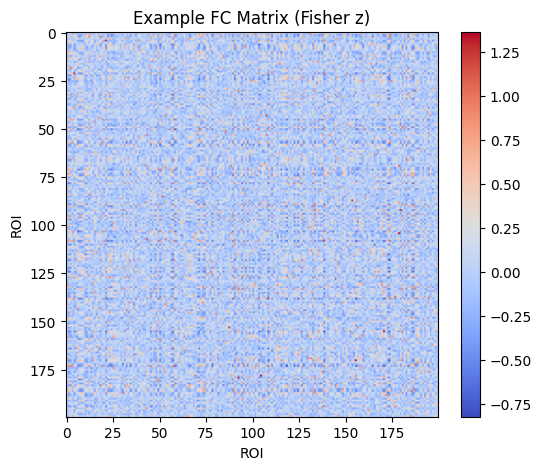

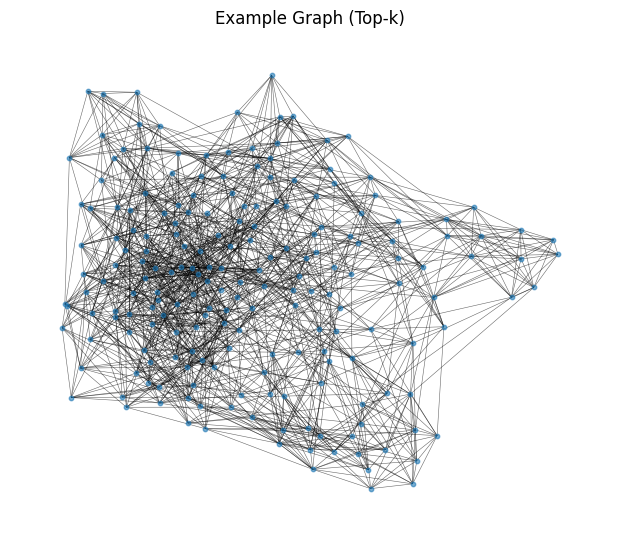

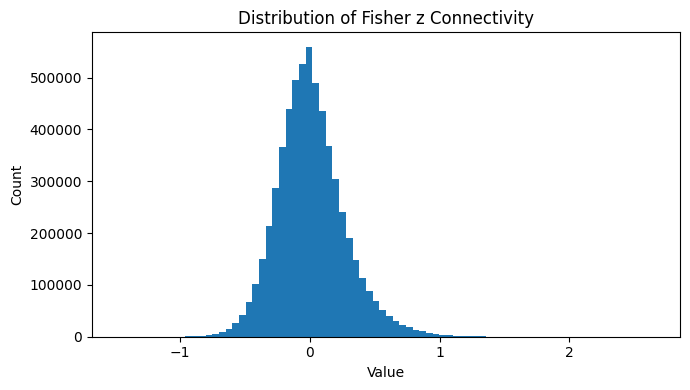

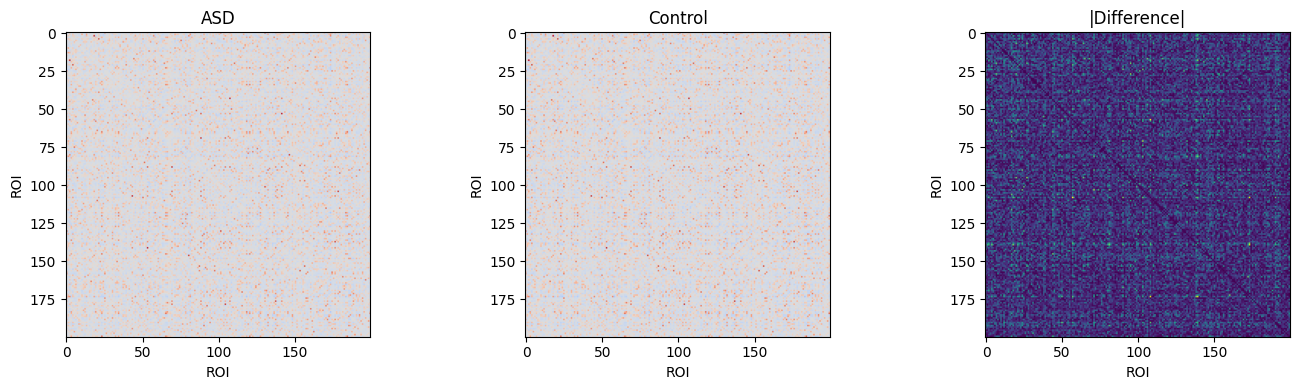

{'example_subject': 'UM_2_0050382',
 'fc_stats': {'mean': 0.009468739852309227,
  'std': 0.2627255320549011,
  'min': -1.4751770496368408,
  'max': 2.6479153633117676},
 'graph_stats': {'num_graphs': 1035,
  'nodes_unique': [200],
  'edges_mean': 1348.6444444444444,
  'edges_std': 58.483204208129806,
  'edges_min': 537,
  'edges_max': 1553}}

In [6]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import networkx as nx
from pathlib import Path

# -----------------------------
# Paths
# -----------------------------
base = Path("data/abide_fmri")
fc_dir = base / "connectivity_matrices"
index_path = base / "connectivity_index.csv"
graph_path = base / "pyg" / "graphs_top10.pt"

# -----------------------------
# Load data
# -----------------------------
index_df = pd.read_csv(index_path)
index_df = index_df[index_df["DX_GROUP"].isin([1, 2])].copy()
index_df["FILE_ID"] = index_df["FILE_ID"].astype(str)
index_df = index_df[index_df["FILE_ID"].apply(lambda fid: (fc_dir / f"{fid}.npy").exists())]

graphs = torch.load(graph_path, weights_only=False)

# -----------------------------
# 1) Example FC matrix
# -----------------------------
rng = np.random.default_rng(42)
example_fid = index_df.sample(1, random_state=42)["FILE_ID"].iloc[0]

fc = np.load(fc_dir / f"{example_fid}.npy")
fc = np.nan_to_num(fc).astype(np.float32)
np.fill_diagonal(fc, 0)

plt.figure(figsize=(6, 5))
plt.imshow(fc, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.title("Example FC Matrix (Fisher z)")
plt.xlabel("ROI")
plt.ylabel("ROI")
plt.show()

# -----------------------------
# 2) Example graph
# -----------------------------
graph_map = {str(getattr(g, "file_id", "")): g for g in graphs}
g = graph_map.get(example_fid, graphs[0])

edge_index = g.edge_index.cpu().numpy()

G = nx.Graph()
G.add_nodes_from(range(g.num_nodes))
G.add_edges_from(edge_index.T.tolist())

plt.figure(figsize=(6, 5))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, node_size=10, width=0.4, alpha=0.6)
plt.title("Example Graph (Top-k)")
plt.axis("off")
plt.show()

# -----------------------------
# 3) FC distribution
# -----------------------------
sample_ids = index_df.sample(n=min(300, len(index_df)), random_state=42)["FILE_ID"]

vals = []
for fid in sample_ids:
    z = np.load(fc_dir / f"{fid}.npy")
    z = np.nan_to_num(z)
    vals.append(z[np.triu_indices_from(z, k=1)])

vals = np.concatenate(vals)

plt.figure(figsize=(7, 4))
plt.hist(vals, bins=80)
plt.title("Distribution of Fisher z Connectivity")
plt.xlabel("Value")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

fc_stats = {
    "mean": float(vals.mean()),
    "std": float(vals.std()),
    "min": float(vals.min()),
    "max": float(vals.max()),
}

# -----------------------------
# 4) Class-level means
# -----------------------------
def mean_fc(ids):
    acc = None
    for fid in ids:
        z = np.load(fc_dir / f"{fid}.npy")
        z = np.nan_to_num(z)
        np.fill_diagonal(z, 0)
        if acc is None:
            acc = np.zeros_like(z, dtype=np.float64)
        acc += z
    return (acc / len(ids)).astype(np.float32)

asd_ids = index_df[index_df["DX_GROUP"] == 1]["FILE_ID"]
ctl_ids = index_df[index_df["DX_GROUP"] == 2]["FILE_ID"]

mean_asd = mean_fc(asd_ids)
mean_ctl = mean_fc(ctl_ids)
diff = np.abs(mean_asd - mean_ctl)

vmax = np.max(np.abs([mean_asd, mean_ctl]))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(mean_asd, cmap="coolwarm", vmin=-vmax, vmax=vmax)
axes[0].set_title("ASD")

axes[1].imshow(mean_ctl, cmap="coolwarm", vmin=-vmax, vmax=vmax)
axes[1].set_title("Control")

axes[2].imshow(diff, cmap="viridis")
axes[2].set_title("|Difference|")

for ax in axes:
    ax.set_xlabel("ROI")
    ax.set_ylabel("ROI")

plt.tight_layout()
plt.show()

# -----------------------------
# 5) Graph stats
# -----------------------------
node_counts = [g.num_nodes for g in graphs]
edge_counts = [g.edge_index.shape[1] // 2 for g in graphs]

graph_stats = {
    "num_graphs": len(graphs),
    "nodes_unique": sorted(set(node_counts)),
    "edges_mean": float(np.mean(edge_counts)),
    "edges_std": float(np.std(edge_counts)),
    "edges_min": int(np.min(edge_counts)),
    "edges_max": int(np.max(edge_counts)),
}

# -----------------------------
# Summary object (optional use)
# -----------------------------
eda_summary = {
    "example_subject": example_fid,
    "fc_stats": fc_stats,
    "graph_stats": graph_stats,
}

eda_summary

# Model Descriptions

## Training Objective

All learned models are trained as binary classifiers using the binary cross-entropy (BCE) loss.

Given a dataset $\{(\mathbf{x}_i, y_i)\}_{i=1}^N$ with labels $y_i \in \{0,1\}$ and predicted probabilities $\hat{y}_i \in (0,1)$, the loss is defined as:
$$
\mathcal{L} = -\frac{1}{N} \sum_{i=1}^N \left[ y_i \log \hat{y}_i + (1 - y_i)\log(1 - \hat{y}_i) \right]
$$

This objective encourages the model to assign high probability to the correct class and penalizes confident incorrect predictions.

Model parameters (e.g., weights and biases) are optimized to minimize this loss over the training data using stochastic gradient-based methods.

## Functions and Notation

We use the following standard functions to explain each model:

- **Sigmoid function**:
  $$
  \sigma(z) = \frac{1}{1 + e^{-z}}
  $$
  Maps a real-valued input to a probability in $(0,1)$.

- **ReLU (Rectified Linear Unit)**:
  $$
  \text{ReLU}(z) = \max(0, z)
  $$

- **LeakyReLU** (used in GAT attention):
  $$
  \text{LeakyReLU}(z) =
  \begin{cases}
  z & \text{if } z \geq 0 \\
  \alpha z & \text{if } z < 0
  \end{cases}
  $$
  where $\alpha$ is a small constant.

- **tanh (hyperbolic tangent)**:
  $$
  \tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}
  $$
  Maps inputs to the range $(-1, 1)$ and is zero-centered.

- **Nonlinear activation $\phi(\cdot)$**:

  Denotes an element-wise nonlinearity. In practice, this is instantiated as ReLU or tanh for MLPs, and ReLU for GNN layers.

- **Indicator function**:
  $$
  \mathbb{I}[\cdot]
  $$
  evaluates to 1 if the condition is true and 0 otherwise.

## Baseline: Predicting the Majority Class

As a reference point, we include a trivial baseline that always predicts the majority class observed in the training data.

In the training split (80/20 stratified), the majority class corresponds to control subjects, yielding a baseline test accuracy of 51.2%. This serves as a minimal benchmark that all learned models are expected to exceed.

## Models Trained on the Matrix Representation

Each subject is represented by the upper triangular entries of the Fisher z-transformed connectivity matrix (excluding the diagonal), yielding a feature vector of size:
$$
\frac{200 \cdot 199}{2} = 19{,}900
$$

Features are standardized using z-scoring based on training data statistics.

### Logistic Regression

Logistic regression provides a linear baseline for classification on vectorized functional connectivity features.
This model learns a single global weight for each connection in the connectivity matrix and combines them linearly. Each feature contributes independently to the prediction, making the model easy to interpret but unable to capture interactions between connections.

#### Mathematical Formulation

The model estimates:
$$
P(y = 1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b)
$$

and is trained by minimizing binary cross-entropy loss.

#### Forward Pass and Prediction

Given input $\mathbf{x}$:

1. Linear score:
   $$
   z = \mathbf{w}^\top \mathbf{x} + b
   $$

2. Probability:
   $$
   \hat{y} = \sigma(z)
   $$

3. Class prediction:
   $$
   \hat{y}_{\text{class}} = \mathbb{I}[\hat{y} \geq 0.5]
   $$

### Multilayer Perceptron (MLP)

The MLP extends logistic regression by introducing non-linear transformations through hidden layers.
Instead of assigning a single weight per feature, the MLP learns hierarchical combinations of connections. Hidden layers allow the model to capture interactions between multiple edges, enabling more complex decision boundaries at the cost of reduced interpretability.

#### Mathematical Formulation

An $L$-layer MLP computes:
$$
\mathbf{h}^{(l)} = \phi(\mathbf{W}^{(l)} \mathbf{h}^{(l-1)} + \mathbf{b}^{(l)})
$$

with output:
$$
\hat{y} = \sigma(\mathbf{W}^{(L)} \mathbf{h}^{(L-1)} + b^{(L)})
$$

#### Forward Pass and Prediction

Given input $\mathbf{x}$:

1. Initialize:
   $$
   \mathbf{h}^{(0)} = \mathbf{x}
   $$

2. Hidden layers (ReLU or tanh applied element-wise):
   $$
   \mathbf{h}^{(l)} = \phi(\mathbf{W}^{(l)} \mathbf{h}^{(l-1)} + \mathbf{b}^{(l)}), \quad l = 1, \dots, L-1
   $$

3. Output logits:
   $$
   z = \mathbf{W}^{(L)} \mathbf{h}^{(L-1)} + b^{(L)}
   $$

4. Probability and prediction:
   $$
   \hat{y} = \sigma(z), \quad
   \hat{y}_{\text{class}} = \mathbb{I}[\hat{y} \geq 0.5]
   $$

## Models Trained on the Graph Representation

Each subject is represented as a graph:
- Nodes: 200 ROIs  
- Edges: top-$k$ strongest connections per node ($k = 10$)  
- Node features: each node is represented by its connectivity profile (200-dimensional)

Node features are normalized per node using row-wise z-scoring.

### Graph Convolutional Network (GCN)

The GCN operates directly on graph-structured functional connectivity data.
The GCN treats the brain as a graph and updates each node by averaging information from its neighbors. This enforces a locality bias: predictions depend on patterns of connectivity within neighborhoods rather than individual edges. The final graph representation summarizes these localized patterns across all nodes.

#### Mathematical Formulation

A GCN layer computes:
$$
\mathbf{H}^{(l+1)} = \phi\left( \tilde{\mathbf{D}}^{-1/2} \tilde{\mathbf{A}} \tilde{\mathbf{D}}^{-1/2} \mathbf{H}^{(l)} \mathbf{W}^{(l)} \right)
$$

#### Forward Pass and Prediction

Given $\mathbf{H}^{(0)} \in \mathbb{R}^{N \times d}$:

1. First layer (ReLU applied after aggregation):
   $$
   \mathbf{H}^{(1)} = \phi(\tilde{\mathbf{A}}_{\text{norm}} \mathbf{H}^{(0)} \mathbf{W}^{(0)})
   $$

2. Second layer:
   $$
   \mathbf{H}^{(2)} = \phi(\tilde{\mathbf{A}}_{\text{norm}} \mathbf{H}^{(1)} \mathbf{W}^{(1)})
   $$

3. Global mean pooling:
   $$
   \mathbf{h}_{\text{graph}} = \frac{1}{N} \sum_{i=1}^{N} \mathbf{h}_i^{(2)}
   $$

4. Classification:
   $$
   \hat{y} = \sigma(\mathbf{w}^\top \mathbf{h}_{\text{graph}} + b), \quad
   \hat{y}_{\text{class}} = \mathbb{I}[\hat{y} \geq 0.5]
   $$

### Graph Attention Network (GAT)

The GAT extends GCN by learning attention weights over neighboring nodes.
Instead of treating all neighbors equally, the GAT learns to weight them based on their relevance. This allows the model to focus on the most informative connections for each node, rather than averaging indiscriminately, leading to a more flexible and adaptive notion of neighborhood structure.


#### Mathematical Formulation

Attention coefficients:
$$
\alpha_{ij} = \frac{\exp(\text{LeakyReLU}(\mathbf{a}^\top [\mathbf{W}\mathbf{h}_i \, \| \, \mathbf{W}\mathbf{h}_j]))}{\sum_{k \in \mathcal{N}(i)} \exp(\cdot)}
$$

Node updates:
$$
\mathbf{h}_i' = \phi\left( \sum_{j \in \mathcal{N}(i)} \alpha_{ij} \mathbf{W}\mathbf{h}_j \right)
$$

#### Forward Pass and Prediction

Given $\{\mathbf{h}_i^{(0)}\}$:

1. First attention layer:
   $$
   \mathbf{h}_i^{(1)} = \phi\left( \sum_{j \in \mathcal{N}(i)} \alpha_{ij} \mathbf{W}^{(0)} \mathbf{h}_j^{(0)} \right)
   $$

2. Second attention layer:
   $$
   \mathbf{h}_i^{(2)} = \phi\left( \sum_{j \in \mathcal{N}(i)} \alpha_{ij}^{(2)} \mathbf{W}^{(1)} \mathbf{h}_j^{(1)} \right)
   $$

3. Global pooling:
   $$
   \mathbf{h}_{\text{graph}} = \frac{1}{N} \sum_{i=1}^{N} \mathbf{h}_i^{(2)}
   $$

4. Classification:
   $$
   \hat{y} = \sigma(\mathbf{w}^\top \mathbf{h}_{\text{graph}} + b), \quad
   \hat{y}_{\text{class}} = \mathbb{I}[\hat{y} \geq 0.5]
   $$

# Training with Cross-Validation and Hyperparameter Tuning

Hyperparameter tuning is performed using 5-fold stratified cross-validation on the training set. Splits are generated using `StratifiedKFold` with shuffling and a fixed random seed (42) to ensure reproducibility.

Model parameters are optimized using stochastic gradient-based methods, with Adam used for neural network models.

For each model and hyperparameter configuration, performance is evaluated using the mean ROC-AUC across validation folds. The configuration with the highest mean ROC-AUC is selected.

For matrix-based models (logistic regression and MLP), tuning is implemented using `GridSearchCV` with `refit=True`, such that the best model is automatically retrained on the full training set. For graph-based models, an equivalent manual grid search is performed over predefined configurations.


## Training Details

Neural network models (MLP, GCN, GAT) are trained using the Adam optimizer.

- **MLP**:
  - Maximum iterations: 600  
  - Early stopping enabled (validation fraction = 0.1)

- **GCN and GAT**:
  - Trained for 60 epochs  
  - ReLU activations applied after each layer  


## Hyperparameter Search

We perform grid search over predefined hyperparameter spaces for each model. All models are evaluated under identical cross-validation settings to ensure comparability of results.

### Logistic Regression

- Regularization type: L1, L2, ElasticNet  
- Solver: `lbfgs` (L2), `saga` (L1, ElasticNet)  
- Regularization strength:
  - L2: $[10^{-4}, 10^{-3}, 10^{-2}, 10^{-1}, 1, 10, 100]$
  - L1: $[10^{-4}, 10^{-3}, 10^{-2}, 10^{-1}, 1, 10]$
  - ElasticNet: $[10^{-3}, 10^{-2}, 10^{-1}, 1, 10]$
- ElasticNet mixing parameter: $\{0.25, 0.5, 0.75\}$
- Class weighting: $\{\text{None}, \text{balanced}\}$
- Maximum iterations: 3000


### Multilayer Perceptron (MLP)

- Hidden layer architectures:
  - $(64)$, $(128)$, $(256)$  
  - $(128, 64)$, $(256, 128)$  
  - $(128, 64, 32)$  
- Activation functions: ReLU, tanh  
- Learning rate: $[10^{-4}, 5 \times 10^{-4}, 10^{-3}]$  
- Batch size: $\{16, 32\}$  
- Additional detail:
  - No dropout (not supported in `sklearn` MLPClassifier)


### Graph Convolutional Network (GCN)

- Hidden dimension: $\{16, 32, 64, 96, 128\}$  
- Dropout: $\{0.2, 0.3, 0.5\}$  
- Learning rate: $\{10^{-3}, 5 \times 10^{-4}\}$  
- Weight decay: $\{0, 10^{-4}\}$  

The GCN hyperparameter space is fully enumerated via grid search over all combinations of the above values. This results in a comprehensive exploration of model capacity and regularization strength under identical training conditions.


### Graph Attention Network (GAT)

Due to the higher computational cost of attention-based message passing, a reduced but structured hyperparameter search space is used for GAT, while preserving comparability with GCN.

- Hidden dimension: $\{16, 32\}$  
- Attention heads (first layer): $\{2, 4\}$  
- Dropout: $\{0.3, 0.5\}$  
- Learning rate: $\{5 \times 10^{-4}, 10^{-3}\}$  
- Weight decay: fixed ($10^{-4}$)

This reduced grid is designed to focus on stable regions identified in the GCN experiments (particularly lower learning rates and stronger regularization), while maintaining variation in model capacity and attention complexity.


## Cross-Validation and Metrics

Cross-validation is used to obtain a more reliable estimate of model performance during hyperparameter selection, particularly given the moderate dataset size. Averaging performance across multiple stratified splits reduces sensitivity to any single train/validation partition and mitigates variance in model selection.

ROC-AUC is used as the primary selection metric. It is computed by plotting the true positive rate against the false positive rate across all possible decision thresholds, and then measuring the area under this curve. Intuitively, it quantifies how well a model ranks positive samples higher than negative samples.

A ROC-AUC of 0.5 corresponds to random guessing, while a value of 1.0 indicates perfect separation between classes. Because it evaluates ranking quality rather than fixed class labels, it is well-suited for model selection during cross-validation, especially when comparing probabilistic classifiers.

During cross-validation, ROC-AUC is computed on each validation fold, and the mean across folds is used to compare hyperparameter configurations.

In [7]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
 )

# Shared modeling constants (used by matrix + graph pipelines)
RANDOM_SEED = 42
CV_FOLDS = 5
GRAPH_BATCH_SIZE = 32
GRAPH_EPOCHS = 60
GAT_DEFAULT_WEIGHT_DECAY = 1e-4
CLASS_NAMES = ["Control", "ASD"]
TUNING_VERBOSE = False

BASE_DIR = Path("data/abide_fmri")
MAT_DIR = BASE_DIR / "connectivity_matrices"
PYG_DIR = BASE_DIR / "pyg"

# Single CV object reused by all models
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)

def load_and_flatten_matrices(file_ids):
    """Load Fisher z-transformed FC matrices and flatten upper triangle."""
    X = []
    for fid in file_ids:
        mat_path = MAT_DIR / f"{fid}.npy"
        if mat_path.exists():
            z = np.load(mat_path)
            z = np.nan_to_num(z).astype(np.float32)
            np.fill_diagonal(z, 0.0)
            features = z[np.triu_indices_from(z, k=1)]  # Extract upper triangle (19,900 dims)
            X.append(features)
    return np.array(X) if X else None

# Get train and test split IDs and labels
train_fids = split_df[split_df["split"] == "train"]["FILE_ID"].values
test_fids = split_df[split_df["split"] == "test"]["FILE_ID"].values

train_labels = split_df[split_df["split"] == "train"]["DX_GROUP"].values
test_labels = split_df[split_df["split"] == "test"]["DX_GROUP"].values

# Convert labels: 1=ASD -> 1, 2=Control -> 0
y_train = np.array([1 if l == 1 else 0 for l in train_labels])
y_test = np.array([1 if l == 1 else 0 for l in test_labels])

# Load Fisher-transformed matrices and flatten
X_matrix_train = load_and_flatten_matrices(train_fids)
X_matrix_test = load_and_flatten_matrices(test_fids)

# Z-score normalization using training set statistics
scaler = StandardScaler()
X_matrix_train = scaler.fit_transform(X_matrix_train)
X_matrix_test = scaler.transform(X_matrix_test)

print(f"Train shape: {X_matrix_train.shape}, Test shape: {X_matrix_test.shape}")
print(f"Class distribution (train): ASD={np.sum(y_train)}, Control={np.sum(y_train == 0)}")
print(f"Class distribution (test):  ASD={np.sum(y_test)}, Control={np.sum(y_test == 0)}")

Train shape: (828, 19900), Test shape: (207, 19900)
Class distribution (train): ASD=404, Control=424
Class distribution (test):  ASD=101, Control=106


In [ ]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression hyperparameter sweep (matches writeup).
param_grid = [
    {
        "penalty": ["l2"],
        "solver": ["lbfgs"],
        "C": [1e-4, 1e-3, 1e-2, 1e-1, 1, 10, 100],
        "class_weight": [None, "balanced"],
    },
    {
        "penalty": ["l1"],
        "solver": ["saga"],
        "C": [1e-4, 1e-3, 1e-2, 1e-1, 1, 10],
        "class_weight": [None, "balanced"],
    },
    {
        "penalty": ["elasticnet"],
        "solver": ["saga"],
        "C": [1e-3, 1e-2, 1e-1, 1, 10],
        "l1_ratio": [0.25, 0.5, 0.75],
        "class_weight": [None, "balanced"],
    },
]

grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=3000, random_state=RANDOM_SEED),
    param_grid=param_grid,
    cv=cv,
    n_jobs=-1,
    scoring="roc_auc",
    verbose=0,
    refit=True,
)

grid.fit(X_matrix_train, y_train)

y_pred = grid.predict(X_matrix_test)
y_pred_proba = grid.predict_proba(X_matrix_test)[:, 1]

print("Logistic Regression winner")
print(f"Best params: {grid.best_params_}")
print(f"Best CV ROC-AUC: {grid.best_score_:.4f}")


In [ ]:
from sklearn.neural_network import MLPClassifier

# MLP hyperparameter sweep (matches writeup).
param_grid_mlp = {
    "hidden_layer_sizes": [
        (64,),
        (128,),
        (256,),
        (128, 64),
        (256, 128),
        (128, 64, 32),
    ],
    "activation": ["relu", "tanh"],
    "learning_rate_init": [1e-4, 5e-4, 1e-3],
    "batch_size": [16, 32],
    "alpha": [1e-4],
}

grid_mlp = GridSearchCV(
    estimator=MLPClassifier(
        max_iter=600,
        random_state=RANDOM_SEED,
        early_stopping=True,
        validation_fraction=0.1,
    ),
    param_grid=param_grid_mlp,
    cv=cv,
    n_jobs=-1,
    scoring="roc_auc",
    verbose=0,
    refit=True,
)

grid_mlp.fit(X_matrix_train, y_train)

y_pred_mlp = grid_mlp.predict(X_matrix_test)
y_pred_proba_mlp = grid_mlp.predict_proba(X_matrix_test)[:, 1]

print("MLP winner")
print(f"Best params: {grid_mlp.best_params_}")
print(f"Best CV ROC-AUC: {grid_mlp.best_score_:.4f}")


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GATConv, global_mean_pool

# Reuse in-memory graph splits; fallback to disk if needed
if "train_graphs" not in globals() or "test_graphs" not in globals():
    train_graphs = torch.load(PYG_DIR / "graphs_top10_train.pt", weights_only=False)
    test_graphs = torch.load(PYG_DIR / "graphs_top10_test.pt", weights_only=False)

# Remove edge_attr from older graph files; this pipeline uses unweighted edges.
for g in (train_graphs + test_graphs):
    if hasattr(g, "edge_attr"):
        del g.edge_attr

# Filter to only labeled graphs (exclude any with y=None)
train_graphs = [g for g in train_graphs if hasattr(g, "y") and g.y is not None]
test_graphs = [g for g in test_graphs if hasattr(g, "y") and g.y is not None]

if len(train_graphs) == 0 or len(test_graphs) == 0:
    raise ValueError("Train/test graph lists are empty after filtering labeled graphs.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Train graphs: {len(train_graphs)} | Test graphs: {len(test_graphs)}")

# Dataset-level sanity checks for the unweighted graph pipeline.
train_example = train_graphs[0]
test_example = test_graphs[0]
print(f"Train graph spec: nodes={train_example.num_nodes}, edges={train_example.edge_index.shape[1]}, unweighted graph used")
print(f"Test graph spec: nodes={test_example.num_nodes}, edges={test_example.edge_index.shape[1]}, unweighted graph used")

in_channels = train_graphs[0].x.shape[1]
num_classes = 2

# Keep graph CV folds aligned with shared CV configuration.
graph_cv_splits = int(cv.n_splits)
print(f"Graph CV folds: {graph_cv_splits}")

def make_loaders(train_data, test_data, batch_size=GRAPH_BATCH_SIZE):
    """Create DataLoaders for graph batching during training/evaluation."""
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

@torch.no_grad()
def predict_labels_and_probs(model, loader):
    """Return y_true, y_prob, y_pred arrays from a graph loader."""
    model.eval()
    ys, probs = [], []

    for batch in loader:
        batch = batch.to(device)
        logits = model(batch)
        p = torch.softmax(logits, dim=1)[:, 1]
        y = batch.y.view(-1).long()

        ys.extend(y.cpu().numpy().tolist())
        probs.extend(p.cpu().numpy().tolist())

    ys = np.array(ys)
    probs = np.array(probs)
    preds = (probs >= 0.5).astype(int)
    return ys, probs, preds

@torch.no_grad()
def evaluate(model, loader):
    """Evaluate model on a graph loader; returns accuracy and ROC-AUC."""
    ys, probs, preds = predict_labels_and_probs(model, loader)
    acc = accuracy_score(ys, preds)
    auc = roc_auc_score(ys, probs) if len(np.unique(ys)) > 1 else np.nan
    return {"acc": acc, "auc": auc}

def train_for_epochs(model, train_loader, lr, weight_decay, epochs=GRAPH_EPOCHS):
    """Train one model for a fixed number of epochs on the provided loader."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    for _ in range(epochs):
        model.train()
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            logits = model(batch)
            y = batch.y.view(-1).long()
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

    return model

def train_one_model(model, train_loader, test_loader, lr, weight_decay, epochs=GRAPH_EPOCHS):
    """Train on train_loader then return metrics on test_loader."""
    model = train_for_epochs(model, train_loader, lr=lr, weight_decay=weight_decay, epochs=epochs)
    return evaluate(model, test_loader)

def cross_validate_graph_model(
    model_builder,
    graphs,
    lr,
    weight_decay,
    epochs=GRAPH_EPOCHS,
    batch_size=GRAPH_BATCH_SIZE,
    n_splits=CV_FOLDS,
    random_state=RANDOM_SEED,
    verbose=False,
 ):
    """Run stratified K-fold CV on training graphs and return aggregate metrics."""
    labels = np.array([int(g.y.view(-1).item()) for g in graphs])
    splitter = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    fold_metrics = []
    for fold_idx, (tr_idx, va_idx) in enumerate(splitter.split(np.zeros(len(graphs)), labels), start=1):
        fold_train = [graphs[i] for i in tr_idx]
        fold_val = [graphs[i] for i in va_idx]

        fold_train_loader = DataLoader(fold_train, batch_size=batch_size, shuffle=True)
        fold_val_loader = DataLoader(fold_val, batch_size=batch_size, shuffle=False)

        model = model_builder()
        model = train_for_epochs(model, fold_train_loader, lr=lr, weight_decay=weight_decay, epochs=epochs)
        metrics = evaluate(model, fold_val_loader)
        fold_metrics.append(metrics)
        if verbose:
            print(f"  Fold {fold_idx}/{n_splits} - acc: {metrics['acc']:.4f}, auc: {metrics['auc']:.4f}")

    accs = np.array([m["acc"] for m in fold_metrics], dtype=float)
    aucs = np.array([m["auc"] for m in fold_metrics], dtype=float)

    return {
        "cv_acc_mean": float(np.nanmean(accs)),
        "cv_acc_std": float(np.nanstd(accs)),
        "cv_auc_mean": float(np.nanmean(aucs)),
        "cv_auc_std": float(np.nanstd(aucs)),
        "fold_metrics": fold_metrics,
    }

class GCNNet(nn.Module):
    """Graph Convolutional Network: 2-layer GCN with dropout and global pooling."""
    def __init__(self, in_channels, hidden_dim=32, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.dropout = dropout
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = global_mean_pool(x, batch)
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.classifier(x)

class GATNet(nn.Module):
    """Graph Attention Network: 2-layer GAT with multi-head attention and global pooling."""
    def __init__(self, in_channels, hidden_dim=32, heads=2, dropout=0.5):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_dim, heads=heads, dropout=dropout)
        self.conv2 = GATConv(hidden_dim * heads, hidden_dim, heads=1, concat=True, dropout=dropout)
        self.dropout = dropout
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        x = F.elu(x)
        x = global_mean_pool(x, batch)
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.classifier(x)

# Keep holdout loaders for final test evaluation.
train_loader, test_loader = make_loaders(train_graphs, test_graphs, batch_size=GRAPH_BATCH_SIZE)
print("Graph setup ready: CV utilities + holdout loaders + model classes defined.")

Device: cpu
Train graphs: 828 | Test graphs: 207
Train graph spec: nodes=200, edges=2654, unweighted graph used
Test graph spec: nodes=200, edges=2732, unweighted graph used
Graph CV folds: 5
Graph setup ready: CV utilities + holdout loaders + model classes defined.


In [ ]:
# GCN hyperparameter configurations (matches writeup search space).
gcn_configs = []
for hidden_dim in [16, 32, 64, 96, 128]:
    for dropout in [0.2, 0.3, 0.5]:
        for lr in [1e-3, 5e-4]:
            for weight_decay in [0.0, 1e-4]:
                gcn_configs.append((hidden_dim, dropout, lr, weight_decay))

gcn_results = []
for hidden_dim, dropout, lr, weight_decay in gcn_configs:
    metrics = cross_validate_graph_model(
        model_builder=lambda: GCNNet(in_channels=in_channels, hidden_dim=hidden_dim, dropout=dropout),
        graphs=train_graphs,
        lr=lr,
        weight_decay=weight_decay,
        epochs=GRAPH_EPOCHS,
        batch_size=GRAPH_BATCH_SIZE,
        n_splits=graph_cv_splits,
        random_state=RANDOM_SEED,
        verbose=TUNING_VERBOSE,
    )

    row = {
        "hidden_dim": hidden_dim,
        "dropout": dropout,
        "lr": lr,
        "weight_decay": weight_decay,
        "cv_acc_mean": metrics["cv_acc_mean"],
        "cv_acc_std": metrics["cv_acc_std"],
        "cv_auc_mean": metrics["cv_auc_mean"],
        "cv_auc_std": metrics["cv_auc_std"],
    }
    gcn_results.append(row)

gcn_results = sorted(
    gcn_results,
    key=lambda x: (np.nan_to_num(x["cv_auc_mean"], nan=-1), x["cv_acc_mean"]),
    reverse=True,
)

print("GCN winner")
print(f"Best params: {gcn_results[0]}")

In [ ]:
# GAT hyperparameter configurations (matches writeup search space).
gat_configs = []
for hidden_dim in [16, 32]:
    for heads in [2, 4]:
        for dropout in [0.3, 0.5]:
            for lr in [5e-4, 1e-3]:
                gat_configs.append((hidden_dim, heads, dropout, lr))
                
gat_results = []
for hidden_dim, heads, dropout, lr in gat_configs:
    metrics = cross_validate_graph_model(
        model_builder=lambda: GATNet(in_channels=in_channels, hidden_dim=hidden_dim, heads=heads, dropout=dropout),
        graphs=train_graphs,
        lr=lr,
        weight_decay=GAT_DEFAULT_WEIGHT_DECAY,
        epochs=GRAPH_EPOCHS,
        batch_size=GRAPH_BATCH_SIZE,
        n_splits=graph_cv_splits,
        random_state=RANDOM_SEED,
        verbose=TUNING_VERBOSE,
    )

    row = {
        "hidden_dim": hidden_dim,
        "heads": heads,
        "dropout": dropout,
        "lr": lr,
        "weight_decay": GAT_DEFAULT_WEIGHT_DECAY,
        "cv_acc_mean": metrics["cv_acc_mean"],
        "cv_acc_std": metrics["cv_acc_std"],
        "cv_auc_mean": metrics["cv_auc_mean"],
        "cv_auc_std": metrics["cv_auc_std"],
    }
    gat_results.append(row)

gat_results = sorted(
    gat_results,
    key=lambda x: (np.nan_to_num(x["cv_auc_mean"], nan=-1), x["cv_acc_mean"]),
    reverse=True,
)

print("GAT winner")
print(f"Best params: {gat_results[0]}")

In [ ]:
print("Logistic Regression winner")
print(f"Best params: {grid.best_params_}")
print(f"Best CV ROC-AUC: {grid.best_score_:.4f}")

print("MLP winner")
print(f"Best params: {grid_mlp.best_params_}")
print(f"Best CV ROC-AUC: {grid_mlp.best_score_:.4f}")

print("GCN winner")
print(f"Best params: {gcn_results[0]}")

print("GAT winner")
print(f"Best params: {gat_results[0]}")

# Evaluation on the Test Set

In [ ]:
# Matrix-model evaluations (already tuned via GridSearchCV)
y_pred_logreg = grid.predict(X_matrix_test)
y_pred_proba_logreg = grid.predict_proba(X_matrix_test)[:, 1]
acc_logreg = accuracy_score(y_test, y_pred_logreg)
auc_logreg = roc_auc_score(y_test, y_pred_proba_logreg)
cm_logreg = confusion_matrix(y_test, y_pred_logreg)

y_pred_mlp = grid_mlp.predict(X_matrix_test)
y_pred_proba_mlp = grid_mlp.predict_proba(X_matrix_test)[:, 1]
acc_mlp = accuracy_score(y_test, y_pred_mlp)
auc_mlp = roc_auc_score(y_test, y_pred_proba_mlp)
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

def evaluate_graph_model_on_test(model_builder, cfg, epochs=GRAPH_EPOCHS):
    """Train on graph train split once, then evaluate on graph test split."""
    model = model_builder()
    model = train_for_epochs(
        model,
        train_loader,
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"],
        epochs=epochs,
    )
    y_true, y_prob, y_pred = predict_labels_and_probs(model, test_loader)
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan
    cm = confusion_matrix(y_true, y_pred)
    return model, acc, auc, cm, y_true, y_prob, y_pred

def print_eval_line(model_name, acc, auc):
    print(f"{model_name}: Accuracy={acc:.4f} | ROC-AUC={auc:.4f}")

# Graph-model evaluations (best config selected by CV)
best_gcn = gcn_results[0]
gcn_model, acc_gcn, auc_gcn, cm_gcn, y_test_gcn, y_pred_gcn_probs, y_pred_gcn = evaluate_graph_model_on_test(
    model_builder=lambda: GCNNet(
        in_channels=in_channels,
        hidden_dim=best_gcn["hidden_dim"],
        dropout=best_gcn["dropout"],
    ),
    cfg=best_gcn,
    epochs=GRAPH_EPOCHS,
)

best_gat = gat_results[0]
gat_model, acc_gat, auc_gat, cm_gat, y_test_gat, y_pred_gat_probs, y_pred_gat = evaluate_graph_model_on_test(
    model_builder=lambda: GATNet(
        in_channels=in_channels,
        hidden_dim=best_gat["hidden_dim"],
        heads=best_gat["heads"],
        dropout=best_gat["dropout"],
    ),
    cfg=best_gat,
    epochs=GRAPH_EPOCHS,
)

# Concise summary for all models
print_eval_line("Logistic Regression", acc_logreg, auc_logreg)
print_eval_line("MLP", acc_mlp, auc_mlp)
print_eval_line("GCN", acc_gcn, auc_gcn)
print_eval_line("GAT", acc_gat, auc_gat)

# Keep table artifact for downstream comparison plots
results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "MLP", "GCN", "GAT"],
    "Accuracy": [acc_logreg, acc_mlp, acc_gcn, acc_gat],
    "ROC-AUC": [auc_logreg, auc_mlp, auc_gcn, auc_gat],
})

In [ ]:
import json
from pathlib import Path
import joblib
import torch

out = Path("data/abide_fmri/model_artifacts")
out.mkdir(parents=True, exist_ok=True)

# Save best hyperparameters and CV scores for all models.
with open(out / "logreg_best_params.json", "w") as f:
    json.dump(grid.best_params_, f, indent=2)
with open(out / "logreg_best_cv_score.json", "w") as f:
    json.dump({"best_cv_score": float(grid.best_score_)}, f, indent=2)
with open(out / "mlp_best_params.json", "w") as f:
    json.dump(grid_mlp.best_params_, f, indent=2)
with open(out / "mlp_best_cv_score.json", "w") as f:
    json.dump({"best_cv_score": float(grid_mlp.best_score_)}, f, indent=2)
with open(out / "gcn_best_params.json", "w") as f:
    json.dump(gcn_results[0], f, indent=2)
with open(out / "gat_best_params.json", "w") as f:
    json.dump(gat_results[0], f, indent=2)

# Save fitted sklearn estimators.
joblib.dump(grid.best_estimator_, out / "logreg_best_model.joblib")
joblib.dump(grid_mlp.best_estimator_, out / "mlp_best_model.joblib")

# Save fitted graph model weights if available.
saved_graph_models = []
if "gcn_model" in globals() and gcn_model is not None:
    torch.save(gcn_model.state_dict(), out / "gcn_best_state.pt")
    saved_graph_models.append("GCN")

if "gat_model" in globals() and gat_model is not None:
    torch.save(gat_model.state_dict(), out / "gat_best_state.pt")
    saved_graph_models.append("GAT")

print(f"Saved model artifacts to {out}")
if saved_graph_models:
    print("Saved graph model weights:", ", ".join(saved_graph_models))
else:
    print("Graph model objects not found; saved graph hyperparameters only.")

In [ ]:
import json
import joblib
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score

artifacts_dir = Path("data/abide_fmri/model_artifacts")

required_files = [
    artifacts_dir / "logreg_best_model.joblib",
    artifacts_dir / "mlp_best_model.joblib",
    artifacts_dir / "logreg_best_params.json",
    artifacts_dir / "mlp_best_params.json",
    artifacts_dir / "logreg_best_cv_score.json",
    artifacts_dir / "mlp_best_cv_score.json",
    artifacts_dir / "gcn_best_params.json",
    artifacts_dir / "gat_best_params.json",
    artifacts_dir / "gcn_best_state.pt",
    artifacts_dir / "gat_best_state.pt",
]

missing = [str(p) for p in required_files if not p.exists()]
if missing:
    raise FileNotFoundError("Missing artifact files:\n- " + "\n- ".join(missing))

# Expect these from earlier setup cells.
required_globals = ["X_matrix_test", "y_test", "test_loader", "in_channels", "device", "GCNNet", "GATNet", "predict_labels_and_probs"]
missing_globals = [name for name in required_globals if name not in globals()]
if missing_globals:
    raise RuntimeError(
        "Missing required in-memory objects. Run data/model setup cells first: "
        + ", ".join(missing_globals)
    )

# Load fitted sklearn models and their saved CV scores.
logreg_model = joblib.load(artifacts_dir / "logreg_best_model.joblib")
mlp_model = joblib.load(artifacts_dir / "mlp_best_model.joblib")

with open(artifacts_dir / "logreg_best_params.json", "r") as f:
    logreg_best_params = json.load(f)
with open(artifacts_dir / "mlp_best_params.json", "r") as f:
    mlp_best_params = json.load(f)
with open(artifacts_dir / "logreg_best_cv_score.json", "r") as f:
    logreg_best_cv = float(json.load(f)["best_cv_score"])
with open(artifacts_dir / "mlp_best_cv_score.json", "r") as f:
    mlp_best_cv = float(json.load(f)["best_cv_score"])

# Load graph best params and instantiate models.
with open(artifacts_dir / "gcn_best_params.json", "r") as f:
    best_gcn = json.load(f)
with open(artifacts_dir / "gat_best_params.json", "r") as f:
    best_gat = json.load(f)

gcn_model = GCNNet(
    in_channels=in_channels,
    hidden_dim=int(best_gcn["hidden_dim"]),
    dropout=float(best_gcn["dropout"]),
).to(device)

gat_model = GATNet(
    in_channels=in_channels,
    hidden_dim=int(best_gat["hidden_dim"]),
    heads=int(best_gat["heads"]),
    dropout=float(best_gat["dropout"]),
).to(device)

gcn_model.load_state_dict(torch.load(artifacts_dir / "gcn_best_state.pt", map_location=device))
gat_model.load_state_dict(torch.load(artifacts_dir / "gat_best_state.pt", map_location=device))
gcn_model.eval()
gat_model.eval()

# Evaluate sklearn models on test matrix features.
y_pred_logreg = logreg_model.predict(X_matrix_test)
y_pred_proba_logreg = logreg_model.predict_proba(X_matrix_test)[:, 1]
acc_logreg = accuracy_score(y_test, y_pred_logreg)
auc_logreg = roc_auc_score(y_test, y_pred_proba_logreg)
cm_logreg = confusion_matrix(y_test, y_pred_logreg)

y_pred_mlp = mlp_model.predict(X_matrix_test)
y_pred_proba_mlp = mlp_model.predict_proba(X_matrix_test)[:, 1]
acc_mlp = accuracy_score(y_test, y_pred_mlp)
auc_mlp = roc_auc_score(y_test, y_pred_proba_mlp)
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

# Evaluate loaded graph models on test graph loader.
y_test_gcn, y_pred_gcn_probs, y_pred_gcn = predict_labels_and_probs(gcn_model, test_loader)
acc_gcn = accuracy_score(y_test_gcn, y_pred_gcn)
auc_gcn = roc_auc_score(y_test_gcn, y_pred_gcn_probs) if len(np.unique(y_test_gcn)) > 1 else np.nan
cm_gcn = confusion_matrix(y_test_gcn, y_pred_gcn)

y_test_gat, y_pred_gat_probs, y_pred_gat = predict_labels_and_probs(gat_model, test_loader)
acc_gat = accuracy_score(y_test_gat, y_pred_gat)
auc_gat = roc_auc_score(y_test_gat, y_pred_gat_probs) if len(np.unique(y_test_gat)) > 1 else np.nan
cm_gat = confusion_matrix(y_test_gat, y_pred_gat)

results_df = pd.DataFrame({
    "Model": ["Logistic Regression", "MLP", "GCN", "GAT"],
    "Accuracy": [acc_logreg, acc_mlp, acc_gcn, acc_gat],
    "ROC-AUC": [auc_logreg, auc_mlp, auc_gcn, auc_gat],
})

param_summary = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "CV ROC-AUC": logreg_best_cv,
        "Best Hyperparameters": logreg_best_params,
        "Test Accuracy": acc_logreg,
        "Test ROC-AUC": auc_logreg,
        "Confusion Matrix": cm_logreg.tolist(),
    },
    {
        "Model": "MLP",
        "CV ROC-AUC": mlp_best_cv,
        "Best Hyperparameters": mlp_best_params,
        "Test Accuracy": acc_mlp,
        "Test ROC-AUC": auc_mlp,
        "Confusion Matrix": cm_mlp.tolist(),
    },
    {
        "Model": "GCN",
        "CV ROC-AUC": best_gcn.get("cv_auc_mean", np.nan),
        "Best Hyperparameters": {
            "hidden_dim": int(best_gcn["hidden_dim"]),
            "dropout": float(best_gcn["dropout"]),
            "lr": float(best_gcn["lr"]),
            "weight_decay": float(best_gcn["weight_decay"]),
        },
        "Test Accuracy": acc_gcn,
        "Test ROC-AUC": auc_gcn,
        "Confusion Matrix": cm_gcn.tolist(),
    },
    {
        "Model": "GAT",
        "CV ROC-AUC": best_gat.get("cv_auc_mean", np.nan),
        "Best Hyperparameters": {
            "hidden_dim": int(best_gat["hidden_dim"]),
            "heads": int(best_gat["heads"]),
            "dropout": float(best_gat["dropout"]),
            "lr": float(best_gat["lr"]),
            "weight_decay": float(best_gat["weight_decay"]),
        },
        "Test Accuracy": acc_gat,
        "Test ROC-AUC": auc_gat,
        "Confusion Matrix": cm_gat.tolist(),
    },
])

# Reorder by test ROC-AUC for readability.
param_summary = param_summary.sort_values("Test ROC-AUC", ascending=False).reset_index(drop=True)

print("=== Tuned Model Summary ===")
for _, row in param_summary.iterrows():
    print(f"\n{row['Model']}")
    print(f"  CV ROC-AUC:   {row['CV ROC-AUC']:.4f}")
    print(f"  Test Accuracy: {row['Test Accuracy']:.4f}")
    print(f"  Test ROC-AUC:  {row['Test ROC-AUC']:.4f}")
    print(f"  Best params:   {row['Best Hyperparameters']}")
    print(f"  Confusion:     {row['Confusion Matrix']}")

print("\n=== Compact Table ===")
print(results_df.sort_values("ROC-AUC", ascending=False).to_string(index=False))

best_acc_idx = results_df["Accuracy"].idxmax()
best_auc_idx = results_df["ROC-AUC"].idxmax()
print(f"\nBest Accuracy: {results_df.loc[best_acc_idx, 'Model']} ({results_df.loc[best_acc_idx, 'Accuracy']:.4f})")
print(f"Best ROC-AUC:  {results_df.loc[best_auc_idx, 'Model']} ({results_df.loc[best_auc_idx, 'ROC-AUC']:.4f})")

NameError: name 'grid' is not defined

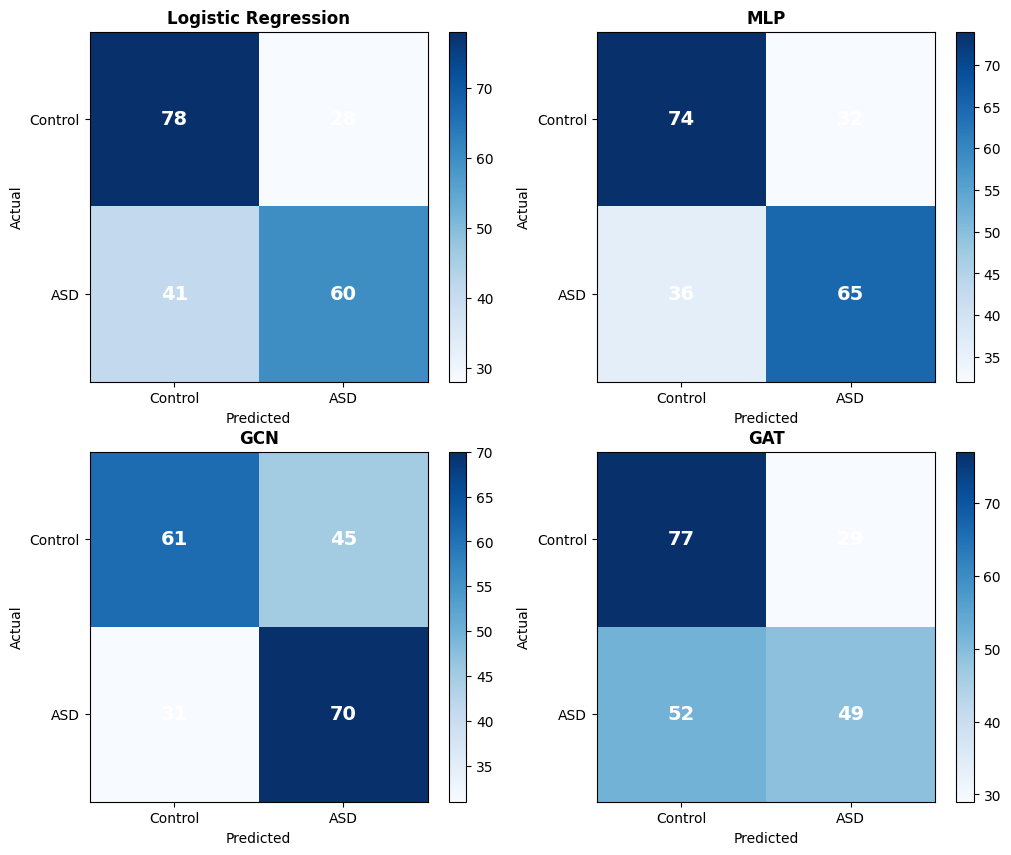

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
models = ["Logistic Regression", "MLP", "GCN", "GAT"]
cms = [cm_logreg, cm_mlp, cm_gcn, cm_gat]
axes = axes.flatten()

for model_name, cm, ax in zip(models, cms, axes):
    im = ax.imshow(cm, cmap="Blues", aspect="auto")
    ax.set_title(model_name, fontsize=12)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(CLASS_NAMES)
    ax.set_yticklabels(CLASS_NAMES)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="white", fontsize=14)
    plt.colorbar(im, ax=ax)

plt.show()

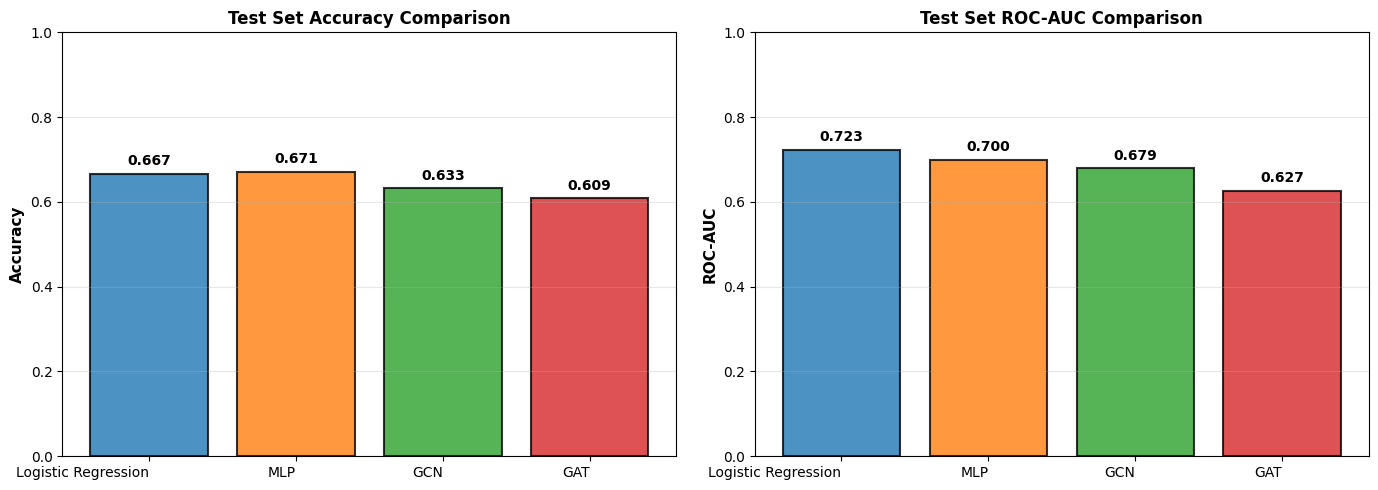

Best Accuracy: MLP (0.6715)
Best ROC-AUC:  Logistic Regression (0.7228)


In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
x_pos = np.arange(len(results_df))

ax1.bar(x_pos, results_df["Accuracy"], color=colors, alpha=0.8, edgecolor="black", linewidth=1.5)
ax1.set_ylabel("Accuracy", fontsize=11)
ax1.set_title("Test Set Accuracy Comparison", fontsize=12)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(results_df["Model"], ha="right")
ax1.set_ylim([0, 1])
ax1.grid(axis="y", alpha=0.3)
for i, v in enumerate(results_df["Accuracy"]):
    ax1.text(i, v + 0.02, f"{v:.3f}", ha="center")

ax2.bar(x_pos, results_df["ROC-AUC"], color=colors, alpha=0.8, edgecolor="black", linewidth=1.5)
ax2.set_ylabel("ROC-AUC", fontsize=11)
ax2.set_title("Test Set ROC-AUC Comparison", fontsize=12)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(results_df["Model"], ha="right")
ax2.set_ylim([0, 1])
ax2.grid(axis="y", alpha=0.3)
for i, v in enumerate(results_df["ROC-AUC"]):
    ax2.text(i, v + 0.02, f"{v:.3f}", ha="center")

plt.tight_layout()
plt.show()

# Summary
best_acc_idx = results_df["Accuracy"].idxmax()
best_auc_idx = results_df["ROC-AUC"].idxmax()
print(f"Best Accuracy: {results_df.loc[best_acc_idx, 'Model']} ({results_df.loc[best_acc_idx, 'Accuracy']:.4f})")
print(f"Best ROC-AUC:  {results_df.loc[best_auc_idx, 'Model']} ({results_df.loc[best_auc_idx, 'ROC-AUC']:.4f})")

# Results and Conclusions 

# Limitations 

# Executive Summary

# AI Statement

# References